# Classification manchots - Perceptron monocouche

Vu que nous avons 3 classes de manchots, on adapte le perceptron à la situation<br>
Chaque neurone dans la couche de sortie correspond à une des classes<br>
Chaque classe possède ses propres poids et son biais, comme si on avait un perceptron par classe<br>
On calculera la sortie de chaque perceptron et celui avec la plus grande valeur sera choisi<br>
En cas d'erreur, les poids de la classe de prédiction seront augmentés et ceux de la classe obtenue seront diminués<br>

On divise l'ensemble des données : 2 Tiers pour l'apprentissage et 1 Tier pour le test<br>
On calculera une moyenne d'erreur apres chaque apprentissage, et chaque test, pour voir graphiquement où on en est<br>
On s'arretera quand on aura fait assez d'"époque" ou quand les erreurs seront satisfaisantes<br>

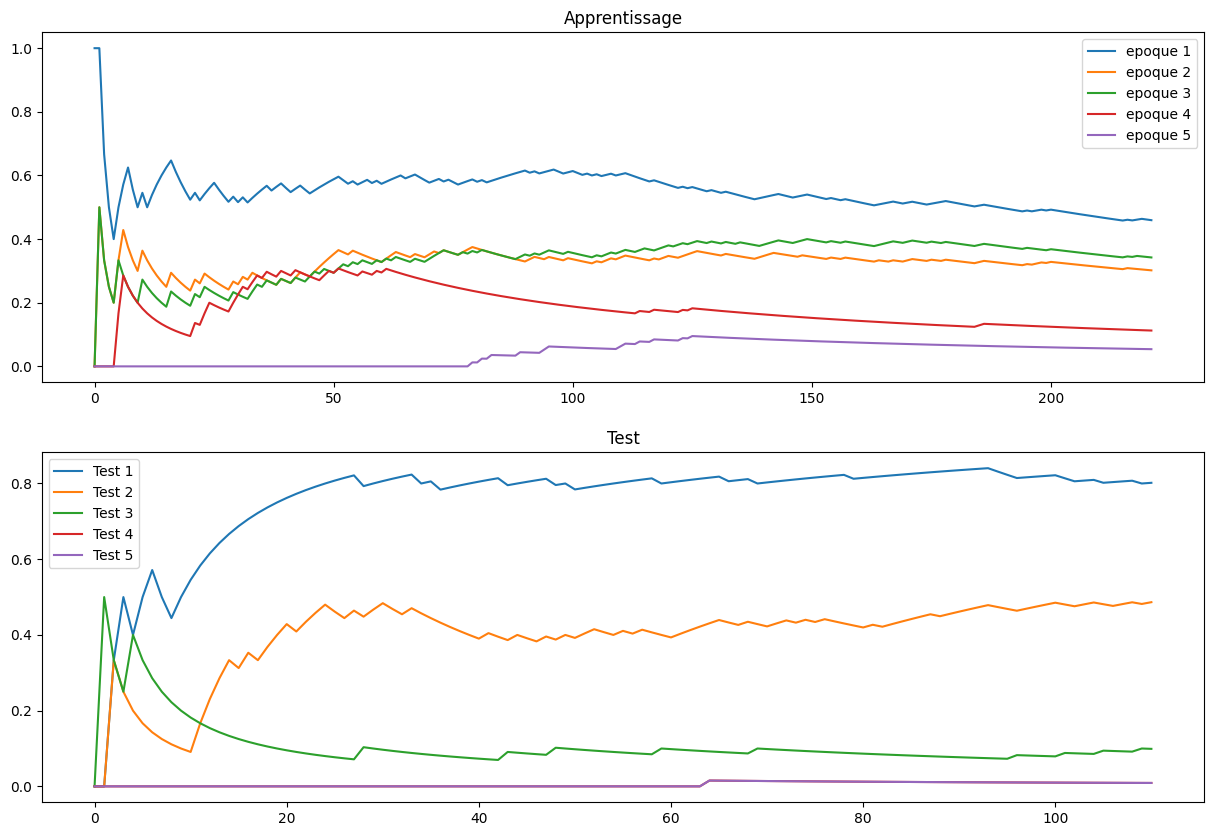

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import random as rd
#import scipy as sy

# lecture de la base de données
df = pd.read_csv("https://raw.githubusercontent.com/allisonhorst/palmerpenguins/c19a904462482430170bfe2c718775ddb7dbb885/inst/extdata/penguins.csv")
df = df.dropna() #Suppr lignes valeurs manquantes
#print(df.head()) #Print 1eres lignes

# matrice des entrées (longueur du bec, largueur du bec, longueur des nageoires, poids du corps)
entrees = df[["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]].to_numpy()

# matrice des sorties (manchot Adélie, manchot Papou, manchot à jugulaire)
sp = ["Adelie","Gentoo","Chinstrap"]
sorties = np.zeros([len(df),len(sp)])
for s in range(len(sp)) :
   sorties[:,s] = df.species==sp[s]

#Normalisation à la main entre 0-1
Enorm = entrees
for i in range(len(Enorm[0])) :
	Max = np.max(Enorm[:,i])
	for j in range(len(Enorm)) :
		Enorm[j][i] = entrees[j][i] / Max
#Enorm = sy.cluster.vq.whiten(entrees)
#print(Enorm)

#Mélange des données
ind = np.arange(len(df))
np.random.shuffle(ind)
sorties = sorties[ind,:]
Enorm = Enorm[ind,:]

#Selection des ensembles
slct = len(Enorm)*2//3
App = Enorm[:slct]
Test = Enorm[slct:]
#print(slct, len(Enorm), len(App), len(Test))

#Initialisation
#rd.randint(-10,10)/10 pour poids random mais trop chaotique selon les itérations
Poids = [[0 for i in range(5)] for j in range(3)]
ConstApp = 0.0005
#print(Poids)

def CalculSortie(Poids, App) :
	Ns = np.zeros(3)
	for k in range(len(Ns)) :
		#Produit vectorielle Poids*Entrées + Biais
		Ns[k] =  np.dot(Poids[k][:4], App[i]) + Poids[k][4]
	return Ns

def Activation(Ns) :
	Act = np.zeros(3)
	Act[np.argmax(Ns)] = 1
	return Act

#Verifie correspondance entre mes neuronnes et sortie connus
def Erreur(Nattendu, Ns) :
	return Nattendu - Ns

#Changement des poids selon les erreurs
def Correction(Err, Poids, Entrees) :
	for i, e in enumerate(Err) : #Pour chaque neuronne
		for j in range(len(Poids[i])-1) :
			Poids[i][j] += e*ConstApp*Entrees[j] #Poids
		Poids[i][4] += e*ConstApp #Biais
	return Poids


fig, axs = plt.subplots(2, 1, figsize=(15, 10))
axs[0].set_title("Apprentissage")
axs[1].set_title("Test")
Legende = [[],[]]

#Parcourt les données
for p in range(5) : #Epoque
	#Pour affichage
	TabErr = [np.zeros(len(App)) for i in range(2)]
	Errmoy = [[],[]]

	#Entrainement
	for i in range(len(App)) :
		#Neurones de sortie
		Ns = CalculSortie(Poids, App)
		Ns = Activation(Ns)
		Err = Erreur(sorties[i], Ns)
		Poids = Correction(Err, Poids, App[i])
		
		TabErr[0][i] = not np.all(Err == 0) #1 si erreur, 0 sinon
		Errmoy[0].append(np.sum(TabErr[0][:i+1])/(i+1))

	Legende[0].append(f'epoque {p+1}')
	axs[0].plot(Errmoy[0])

	#Test
	for i in range(len(Test)) :
		#Neurones de sortie
		Ns = CalculSortie(Poids, Test)
		Ns = Activation(Ns)
		Err = Erreur(sorties[slct+i], Ns)
		
		TabErr[1][i] = not np.all(Err == 0)
		Errmoy[1].append(np.sum(TabErr[1][:i+1])/(i+1))

	Legende[1].append(f'Test {p+1}')
	axs[1].plot(Errmoy[1])
	

axs[0].legend(Legende[0])
axs[1].legend(Legende[1])
plt.show()